# TIME SERIES CLASSIFICATION USING LSTM

## IMPORT LIBRARIES

In [1]:
import numpy as np # mathematical operations and array handling
import pandas as pd # Pandas for loading and handling tabular dataset
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns # better visualization of confusion matrix
from tensorflow.keras.models import Sequential # model allows stacking layers one after another
from tensorflow.keras.layers import (
    Input,
    LSTM,          # Long Term Memory using a memory cell and gating mechanisms
    Dense          # Dense → fully connected classification layers
)
from tensorflow.keras.callbacks import EarlyStopping # prevents overfitting
from sklearn.model_selection import train_test_split # Train-test split for model evaluation
from sklearn.preprocessing import StandardScaler # StandardScaler for feature normalization
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics

## LOAD DATASET

- This dataset (module_159_data.csv) is assumed to be a structured
- time-series / sequential feature dataset

In [2]:
df = pd.read_csv("module_159_data.csv")

print("Dataset shape:", df.shape)


Dataset shape: (2000, 11)


In [3]:
X = df.drop("target", axis=1).values
y = df["target"].values

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (2000, 10)
Target shape: (2000,)


## FEATURE SCALING

RNNs are sensitive to scale because they perform repeated multiplication

Standardization formula:
`z = (x - μ) / σ`

 where:
- μ = mean
- σ = standard deviation

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## RESHAPING FOR RNN

RNN expects 3D input: `(samples, timesteps, features)`

Here we treat each feature as a timestep

WARNING: This assumes features have sequential meaning

In [5]:
X = X.reshape((X.shape[0], X.shape[1], 1))
print("RNN input shape:", X.shape)

RNN input shape: (2000, 10, 1)


## TRAIN TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600, 10, 1)
Testing shape: (400, 10, 1)


## BUILD RNN MODEL

- **LSTM LAYER:**
LSTM is an improved RNN that can learn long-term dependencies using a memory cell and gating mechanisms.

  - Forget Gate:
    f_t = σ(W_f x_t + U_f h_{t-1} + b_f)
    Controls what information to discard.

  - Input Gate:
    i_t = σ(W_i x_t + U_i h_{t-1} + b_i)
    C̃_t = tanh(W_c x_t + U_c h_{t-1} + b_c)
    Controls what new information to store.

  - Cell State Update:
    C_t = f_t * C_{t-1} + i_t * C̃_t

  - Output Gate:
    o_t = σ(W_o x_t + U_o h_{t-1} + b_o)
    h_t = o_t * tanh(C_t)
    Controls the final output.

  where:
  - x_t = input at time step t
  - h_{t-1} = previous hidden state
  - C_{t-1} = previous cell state
  - h_t = current hidden state
  - C_t = current cell state

- **Dense:** Output Layer
    - Binary classification output

In [7]:
model = Sequential([

    Input(shape=(10,1)),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## COMPILE MODEL

**Optimizer:** Adam combines Momentum and Adaptive learning rate
  - Weight update idea: `θ = θ - α * gradient`

**Loss function:** Binary Crossentropy
  - `L = -[y log(p) + (1-y) log(1-p)]`

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## TRAIN MODEL

- Early stopping prevents overfitting
- Stops training when validation loss stops improving

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6477 - loss: 0.6563 - val_accuracy: 0.8313 - val_loss: 0.5778
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8453 - loss: 0.4528 - val_accuracy: 0.8875 - val_loss: 0.3663
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8805 - loss: 0.3222 - val_accuracy: 0.9062 - val_loss: 0.2674
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9008 - loss: 0.2479 - val_accuracy: 0.9375 - val_loss: 0.2156
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9187 - loss: 0.2088 - val_accuracy: 0.9438 - val_loss: 0.1628
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9297 - loss: 0.1741 - val_accuracy: 0.9531 - val_loss: 0.1438
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9375 - loss: 0.1484 - val_accuracy: 0.9688 - val_loss: 0.1251
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9469 - loss: 0.1377 - val_accuracy: 0.9844 - val_los

## EVALUATION
- Precision = TP / (TP + FP)
- Recall    = TP / (TP + FN)
- F1 Score  = 2PR / (P + R)

In [11]:
# ACCURACY AND LOSS
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss, 4))
print(f"Test Accuracy: {test_acc:4f} -> {test_acc:2%}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9750 - loss: 0.0619  
Test Loss: 0.0619
Test Accuracy: 0.975000 -> 97.500002%


In [12]:
# PREDICTIONS
y_prob = model.predict(X_test)

# Convert probabilities using threshold 0.5 → class labels
y_pred = (y_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [13]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       204
           1       0.98      0.96      0.97       196

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400



In [14]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm

array([[201,   3],
       [  7, 189]])

## VISUALIZATIONS

### CONFUSION MATRIX

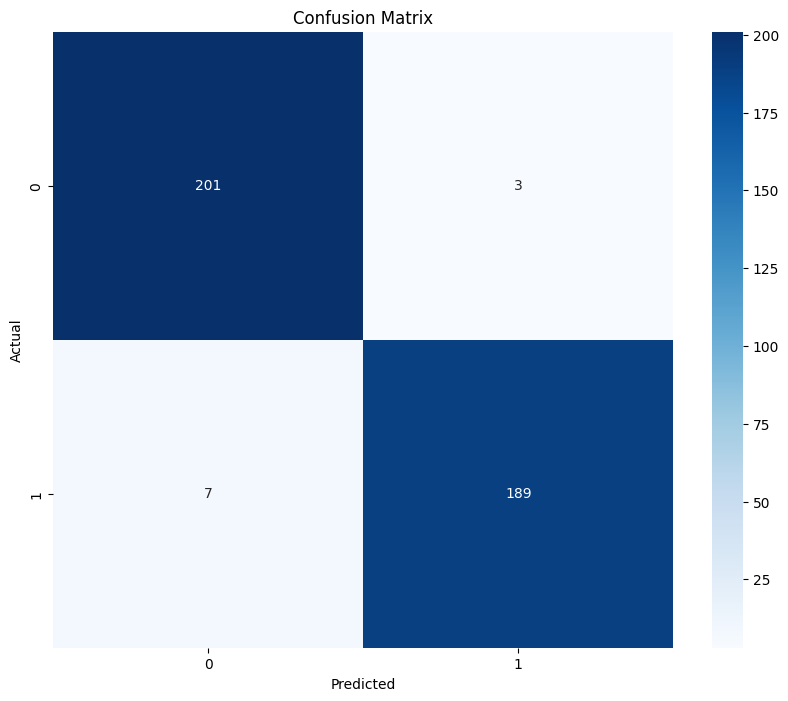

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
    )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### TRAINING CURVES

#### Loss Curve

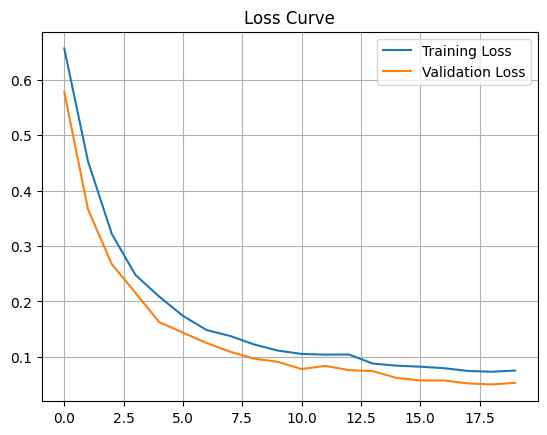

In [16]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

#### Accuracy Curve

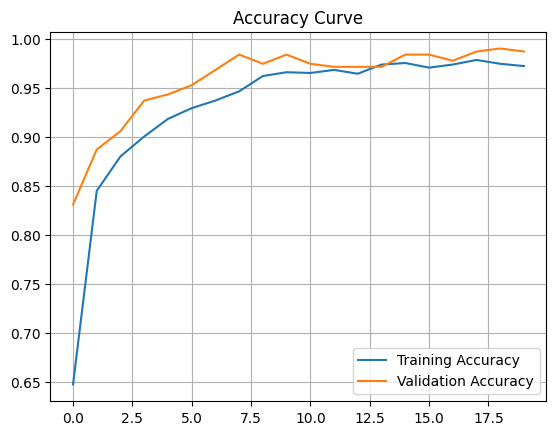

In [17]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

## LSTM SUMMARY:

1. LSTM is designed for sequential / time-series data
2. It uses cell state and hidden state to capture long-term dependencies
3. Each step depends on previous computations through gated memory

**Hidden state:**
h_t = o_t * tanh(C_t)

**Cell state:**
C_t = f_t * C_{t-1} + i_t * C̃_t

**Output:**
y = sigmoid(W * h_t)

**Loss:**
Binary Crossentropy

Important note:
LSTM is only meaningful when data has sequence structure.
If features are artificial sequences, interpretation must be careful.

**Final result:**
Model learns short-term and long-term patterns over sequences and performs binary classification.